In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Nat_Gas.csv")

In [3]:
df['Dates'] = pd.to_datetime(df['Dates'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_9832\2452315616.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


In [4]:
df.head()

,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


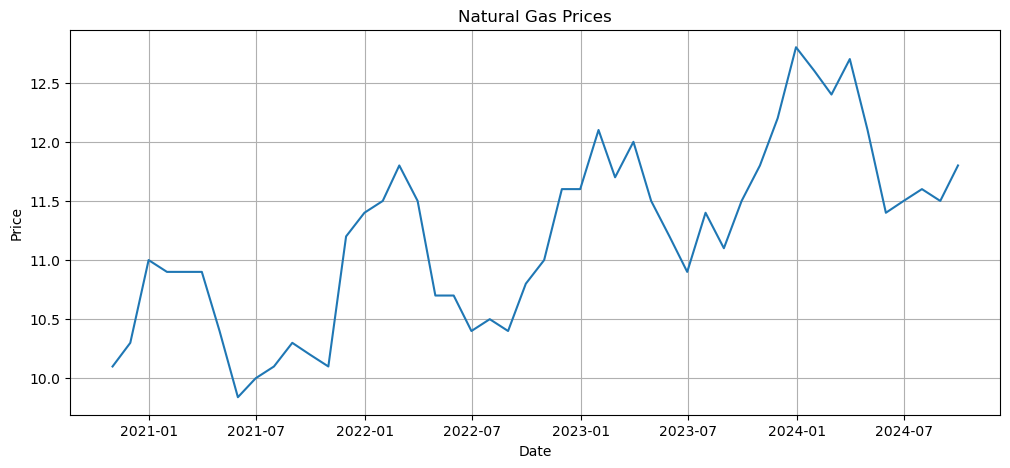

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df['Dates'], df['Prices'])
plt.title("Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

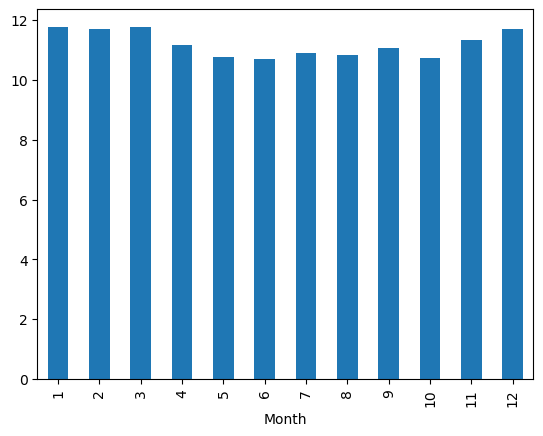

In [6]:
df['Month'] = df['Dates'].dt.month

monthly_avg = df.groupby('Month')['Prices'].mean()

monthly_avg.plot(kind='bar')
plt.show()

In [7]:
# Create daily data from monthly snapshots

daily_df = (
    df.set_index('Dates')
      .resample('D')
      .interpolate(method='linear')
)

daily_df.head()

,Prices,Month
Dates,,
2020-10-31,10.100000,10.000000
2020-11-01,10.106667,10.033333
2020-11-02,10.113333,10.066667
2020-11-03,10.120000,10.100000
2020-11-04,10.126667,10.133333


In [8]:
# Monthly average prices by month
monthly_avg = df.groupby(df['Dates'].dt.month)['Prices'].mean()

# Create future month-end dates
future_dates = pd.date_range(
    start='2024-10-31',
    periods=12,
    freq='ME'
)

future_prices = [
    monthly_avg[d.month]
    for d in future_dates
]

future_df = pd.DataFrame({
    'Dates': future_dates,
    'Prices': future_prices
})

In [9]:
combined_df = pd.concat([
    df[['Dates', 'Prices']],
    future_df
])

combined_df = combined_df.sort_values('Dates')

In [10]:
combined_daily = (
    combined_df
    .set_index('Dates')
    .resample('D')
    .interpolate(method='linear')
)

combined_daily.head()

,Prices
Dates,
2020-10-31,10.100000
2020-11-01,10.106667
2020-11-02,10.113333
2020-11-03,10.120000
2020-11-04,10.126667


In [11]:
combined_daily.loc['2025-03-15']

Prices    11.73629
Name: 2025-03-15 00:00:00, dtype: float64

In [12]:
def estimate_price(date):
    date = pd.to_datetime(date)
    return float(combined_daily.loc[date, 'Prices'])

In [14]:
estimate_price("2023-07-15")

11.141935483870968

In [29]:
def value_contract(
    injection_date,
    withdrawal_date,
    volume,
    max_storage_volume,
    injection_rate,
    withdrawal_rate,
    storage_cost_per_day
):

    # Check storage capacity
    if volume > max_storage_volume:
        raise ValueError(
            "Volume exceeds maximum storage capacity"
        )

    # Get prices from Task 1 model
    buy_price = estimate_price(injection_date)
    sell_price = estimate_price(withdrawal_date)

    # Days needed to inject and withdraw gas
    injection_days = volume / injection_rate
    withdrawal_days = volume / withdrawal_rate

    # Storage duration
    storage_days = (
        pd.to_datetime(withdrawal_date)
        - pd.to_datetime(injection_date)
    ).days

    # Total storage cost
    total_storage_cost = (
        storage_days * storage_cost_per_day
    )

    # Cash flows
    purchase_cost = volume * buy_price
    sale_revenue = volume * sell_price

    # Contract value
    contract_value = (
        sale_revenue
        - purchase_cost
        - total_storage_cost
    )

    return {
        "Buy Price": round(buy_price, 2),
        "Sell Price": round(sell_price, 2),
        "Purchase Cost": round(purchase_cost, 2),
        "Sale Revenue": round(sale_revenue, 2),
        "Storage Cost": round(total_storage_cost, 2),
        "Injection Days": round(injection_days, 2),
        "Withdrawal Days": round(withdrawal_days, 2),
        "Contract Value": round(contract_value, 2)
    }

In [31]:
value_contract(
    injection_date="2024-06-01",
    withdrawal_date="2024-12-01",
    volume=1000,
    max_storage_volume=5000,
    injection_rate=200,
    withdrawal_rate=250,
    storage_cost_per_day=2
)

{'Buy Price': 11.4,
 'Sell Price': 11.34,
 'Purchase Cost': 11403.33,
 'Sale Revenue': 11337.1,
 'Storage Cost': 366,
 'Injection Days': 5.0,
 'Withdrawal Days': 4.0,
 'Contract Value': -432.24}

In [32]:
value_contract(
    injection_date="2024-05-01",
    withdrawal_date="2025-01-01",
    volume=2000,
    max_storage_volume=10000,
    injection_rate=300,
    withdrawal_rate=300,
    storage_cost_per_day=1.5
)

{'Buy Price': 12.08,
 'Sell Price': 11.7,
 'Purchase Cost': 24154.84,
 'Sale Revenue': 23404.84,
 'Storage Cost': 367.5,
 'Injection Days': 6.67,
 'Withdrawal Days': 6.67,
 'Contract Value': -1117.5}